# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

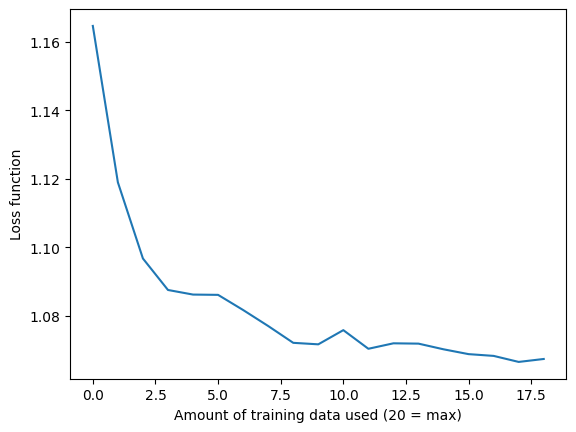

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

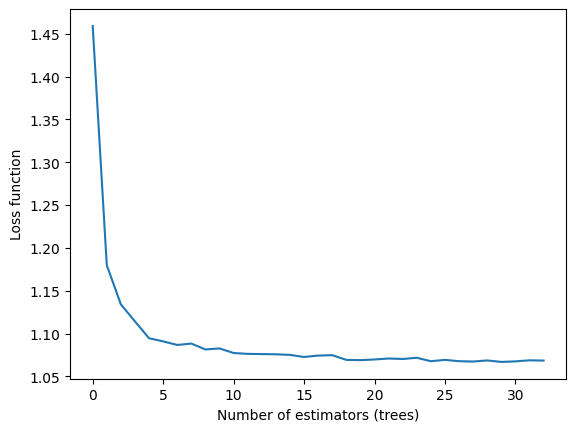

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [7]:
predict_conversion_df = pd.read_csv("predict-conversion-dataset.csv")

In [8]:
# Random Forest Regressor for predict_conversion_df

from sklearn.model_selection import train_test_split

# Drop ID column and encode
features = predict_conversion_df.drop(columns=["CustomerID", "Conversion"])
target = predict_conversion_df["Conversion"]

features_encoded = pd.get_dummies(features, drop_first=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42
)

# Fit Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Evaluate
y_pred_reg = rf_reg.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred_reg)
print(f"Test RMSE: {rmse:.4f}")


Test RMSE: 0.2828


In [9]:
# Cross-validation for predict_conversion_df

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_reg,
    features_encoded,
    target,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores
print("Cross-validation RMSE per fold:", cv_rmse.round(4))
print(f"Mean RMSE: {cv_rmse.mean():.4f}  |  Std: {cv_rmse.std():.4f}")


Cross-validation RMSE per fold: [0.2156 0.2298 0.2269 0.2277 0.4714]
Mean RMSE: 0.2743  |  Std: 0.0987


Folds one through four are tightly clustered, showing that the model generalizes consistently on most of the data, and the fifth fold nearly doubles this error. Because the data is not shuffled by default and the last portion of the folds differed greatly, it is highly likely that the dataset has some structure or ordering. The high standard deviation along with the mean RMSE indicates that the dataset is likely not independently and identically distributed. 

In [10]:
# Tuning hyperparameters for predict_conversion_df using GridSearchCV

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_search.fit(features_encoded, target)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV RMSE:    {-grid_search.best_score_:.4f}")

Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE:    0.2677


In [11]:
google_ads_df = pd.read_csv("google-ads-dataset.csv")

In [12]:
# Random forest regressor for google_ads_df

# Clean dollar-sign columns and drop non-predictive columns
ads = google_ads_df.assign(
    Cost=google_ads_df["Cost"].str.replace("$", "", regex=False).astype(float),
    Sale_Amount=google_ads_df["Sale_Amount"].str.replace("$", "", regex=False).astype(float)
).dropna(subset=["Sale_Amount"])

ads_features = ads.drop(columns=["Ad_ID", "Ad_Date", "Sale_Amount"])
ads_target = ads["Sale_Amount"]

ads_features_encoded = pd.get_dummies(ads_features, drop_first=True)

X_train_ads, X_test_ads, y_train_ads, y_test_ads = train_test_split(
    ads_features_encoded, ads_target, test_size=0.2, random_state=42
)

rf_ads = RandomForestRegressor(n_estimators=100, random_state=42)
rf_ads.fit(X_train_ads, y_train_ads)

y_pred_ads = rf_ads.predict(X_test_ads)
rmse_ads = root_mean_squared_error(y_test_ads, y_pred_ads)
print(f"Test RMSE: {rmse_ads:.2f}")


Test RMSE: 296.18


In [13]:
# Cross-validation for google_ads_df

cv_scores_ads = cross_val_score(
    rf_ads,
    ads_features_encoded,
    ads_target,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse_ads = -cv_scores_ads
print("Cross-validation RMSE per fold:", cv_rmse_ads.round(2))
print(f"Mean RMSE: {cv_rmse_ads.mean():.2f}  |  Std: {cv_rmse_ads.std():.2f}")


Cross-validation RMSE per fold: [301.83 291.28 284.95 294.06 294.57]
Mean RMSE: 293.34  |  Std: 5.46


In [14]:
# Tuning hyperparameters for google_ads_df using GridSearchCV

param_grid_ads = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

grid_search_ads = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_ads,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_search_ads.fit(ads_features_encoded, ads_target)

print("Best parameters:", grid_search_ads.best_params_)
print(f"Best CV RMSE:    {-grid_search_ads.best_score_:.2f}")


Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV RMSE:    290.06


This tuned CV RMSE reveals that a hyperparameter search has exhausted its gains, with an improvement of $3.28 across 18 hyperparameter combinations. This could be an opportunity to turn towards feature engineearing for improvement.

In [15]:
marketing_and_productdf = pd.read_csv("marketing-and-product-dataset.csv")

In [ ]:
# Random forest regressor for marketing_and_productdf

id_cols = ["Campaign_ID", "Product_ID", "Customer_ID", "Flash_Sale_ID", "Bundle_ID"]
mp = marketing_and_productdf.drop(columns=id_cols)

mp_features = mp.drop(columns=["Revenue_Generated"])
mp_target = mp["Revenue_Generated"]

mp_features_encoded = pd.get_dummies(mp_features, drop_first=True)

X_train_mp, X_test_mp, y_train_mp, y_test_mp = train_test_split(
    mp_features_encoded, mp_target, test_size=0.2, random_state=42
)

rf_mp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_mp.fit(X_train_mp, y_train_mp)

y_pred_mp = rf_mp.predict(X_test_mp)
rmse_mp = root_mean_squared_error(y_test_mp, y_pred_mp)
print(f"Test RMSE: {rmse_mp:.2f}")


Test RMSE: 29014.39


In [ ]:
# Cross-validation for marketing_and_productdf

cv_scores_mp = cross_val_score(
    rf_mp,
    mp_features_encoded,
    mp_target,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse_mp = -cv_scores_mp
print("Cross-validation RMSE per fold:", cv_rmse_mp.round(2))
print(f"Mean RMSE: {cv_rmse_mp.mean():.2f}  |  Std: {cv_rmse_mp.std():.2f}")


Cross-validation RMSE per fold: [29240.94 28515.3  29290.42 28766.88 28992.78]
Mean RMSE: 28961.26  |  Std: 291.28


The consistent folds in addition to the negligible tuing gain demonstrat that the model and data are a good match. It reveals an inherent structural consistenty in the dataset 

In [ ]:
## Performance Metric Evaluation — marketing_and_productdf

param_grid_mp = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

grid_search_mp = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_mp,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
grid_search_mp.fit(mp_features_encoded, mp_target)

print("Best parameters:", grid_search_mp.best_params_)
print(f"Best CV RMSE:    {-grid_search_mp.best_score_:.2f}")


Best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE:    28654.33


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

I cannot find any graphs in chapter 7 between p. 165-185.